# 04 - Modelling

Predict resistance to ceftriaxone, ciprofloxacin and gentamicin from AMR gene
presence/absence. Three model types are compared with stratified 5-fold
cross-validation against a no-skill baseline. Because the classes are imbalanced,
models are judged on ROC-AUC, balanced accuracy, average precision and F1 rather
than plain accuracy.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path.home() / "amr-project"
PROC = ROOT / "data" / "processed"
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

X = pd.read_csv(PROC / "gene_matrix_filtered.csv", index_col=0, dtype={"genome_id": str})
y = pd.read_csv(PROC / "labels_clean.csv", index_col=0, dtype={"genome_id": str})
X.index = X.index.astype(str)
y.index = y.index.astype(str)
y = y.loc[X.index]
assert (X.index == y.index).all()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "bal_acc": "balanced_accuracy",
           "avg_prec": "average_precision", "f1": "f1"}

print("Features:", X.shape, " Labels:", y.shape)

Features: (2411, 102)  Labels: (2411, 3)


In [2]:
rows = []
for drug in y.columns:
    yy = y[drug].astype(int)
    res = cross_validate(DummyClassifier(strategy="most_frequent"), X, yy,
                         cv=cv, scoring=scoring)
    rows.append({"drug": drug, "model": "Baseline (majority class)",
                 **{m: res[f"test_{m}"].mean() for m in scoring}})

baseline = pd.DataFrame(rows).round(3)
baseline

,drug,model,roc_auc,bal_acc,avg_prec,f1
0,ceftriaxone,Baseline (majority class),0.5,0.5,0.830,0.907
1,ciprofloxacin,Baseline (majority class),0.5,0.5,0.764,0.866
2,gentamicin,Baseline (majority class),0.5,0.5,0.416,0.000


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

models = {
    "Logistic regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=42, n_jobs=-1),
    "Gradient boosting": HistGradientBoostingClassifier(class_weight="balanced",
                                                        random_state=42),
}

rows = []
for drug in y.columns:
    yy = y[drug].astype(int)
    for name, model in models.items():
        res = cross_validate(model, X, yy, cv=cv, scoring=scoring)
        row = {"drug": drug, "model": name}
        for m in scoring:
            row[m] = res[f"test_{m}"].mean()
            row[f"{m}_sd"] = res[f"test_{m}"].std()
        rows.append(row)
        print(f"done: {drug} / {name}  AUC={row['roc_auc']:.3f}")

results = pd.concat([baseline, pd.DataFrame(rows)], ignore_index=True)
results.to_csv(PROC / "model_results.csv", index=False)

done: ceftriaxone / Logistic regression  AUC=0.991
done: ceftriaxone / Random forest  AUC=0.990
done: ceftriaxone / Gradient boosting  AUC=0.988
done: ciprofloxacin / Logistic regression  AUC=0.989
done: ciprofloxacin / Random forest  AUC=0.987
done: ciprofloxacin / Gradient boosting  AUC=0.991
done: gentamicin / Logistic regression  AUC=0.977
done: gentamicin / Random forest  AUC=0.979
done: gentamicin / Gradient boosting  AUC=0.978


In [4]:
cols = ["drug", "model", "roc_auc", "bal_acc", "avg_prec", "f1"]
results[cols].round(3).sort_values(["drug", "roc_auc"], ascending=[True, False])

,drug,model,roc_auc,bal_acc,avg_prec,f1
3,ceftriaxone,Logistic regression,0.991,0.973,0.998,0.982
4,ceftriaxone,Random forest,0.990,0.966,0.996,0.985
5,ceftriaxone,Gradient boosting,0.988,0.968,0.996,0.986
0,ceftriaxone,Baseline (majority class),0.500,0.500,0.830,0.907
8,ciprofloxacin,Gradient boosting,0.991,0.959,0.997,0.978
6,ciprofloxacin,Logistic regression,0.989,0.958,0.996,0.971
7,ciprofloxacin,Random forest,0.987,0.956,0.994,0.974
1,ciprofloxacin,Baseline (majority class),0.500,0.500,0.764,0.866
10,gentamicin,Random forest,0.979,0.944,0.971,0.934
11,gentamicin,Gradient boosting,0.978,0.954,0.970,0.947


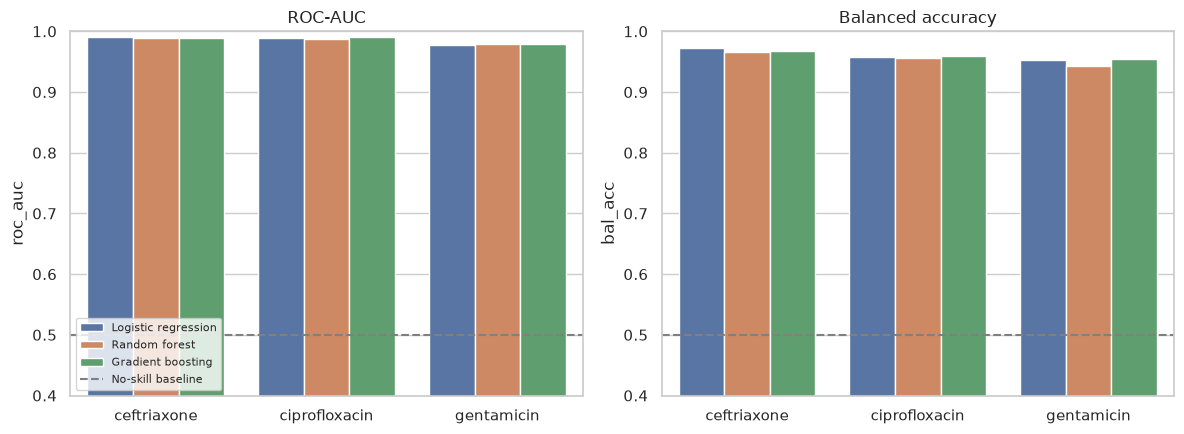

In [5]:
plot_df = results[results["model"] != "Baseline (majority class)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, metric, title in zip(axes, ["roc_auc", "bal_acc"],
                             ["ROC-AUC", "Balanced accuracy"]):
    sns.barplot(data=plot_df, x="drug", y=metric, hue="model", ax=ax)
    ax.axhline(0.5, color="grey", linestyle="--", label="No-skill baseline")
    ax.set_ylim(0.4, 1.0)
    ax.set_title(title)
    ax.set_xlabel("")
axes[0].legend(loc="lower left", fontsize=8)
axes[1].get_legend().remove()
plt.tight_layout()
plt.savefig(FIG / "model_comparison.png", dpi=150)
plt.show()

In [6]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

# group genomes whose gene profiles differ at fewer than ~5% of the 102 genes
Z = linkage(pdist(X.values, metric="hamming"), method="average")
groups = fcluster(Z, t=0.05, criterion="distance")
print("Number of lineage groups:", len(np.unique(groups)))
print("Largest group size:", pd.Series(groups).value_counts().max())

gcv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for drug in y.columns:
    yy = y[drug].astype(int)
    for name, model in [("Logistic regression",
                         LogisticRegression(max_iter=2000, class_weight="balanced")),
                        ("Gradient boosting",
                         HistGradientBoostingClassifier(class_weight="balanced",
                                                        random_state=42))]:
        res = cross_validate(model, X, yy, cv=gcv, groups=groups, scoring=scoring)
        rows.append({"drug": drug, "model": name,
                     "roc_auc": res["test_roc_auc"].mean(),
                     "roc_auc_sd": res["test_roc_auc"].std(),
                     "bal_acc": res["test_bal_acc"].mean()})

group_results = pd.DataFrame(rows).round(3)
group_results.to_csv(PROC / "model_results_grouped.csv", index=False)
group_results

Number of lineage groups: 329
Largest group size: 236


,drug,model,roc_auc,roc_auc_sd,bal_acc
0,ceftriaxone,Logistic regression,0.981,0.009,0.948
1,ceftriaxone,Gradient boosting,0.984,0.007,0.936
2,ciprofloxacin,Logistic regression,0.977,0.014,0.912
3,ciprofloxacin,Gradient boosting,0.981,0.010,0.922
4,gentamicin,Logistic regression,0.964,0.015,0.944
5,gentamicin,Gradient boosting,0.962,0.021,0.944


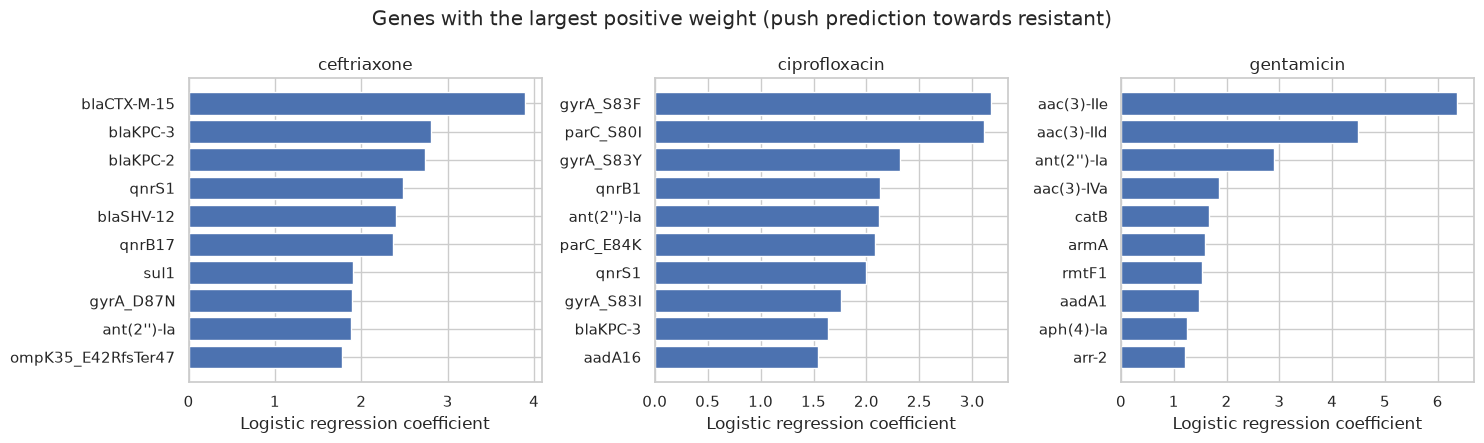

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, drug in zip(axes, y.columns):
    lr = LogisticRegression(max_iter=2000, class_weight="balanced")
    lr.fit(X, y[drug].astype(int))
    coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values(ascending=False).head(10)[::-1]
    ax.barh(coefs.index, coefs.values)
    ax.set_title(drug)
    ax.set_xlabel("Logistic regression coefficient")
plt.suptitle("Genes with the largest positive weight (push prediction towards resistant)")
plt.tight_layout()
plt.savefig(FIG / "model_top_genes.png", dpi=150)
plt.show()

## Summary

**Setup.** Logistic regression, random forest and gradient boosting were trained on
the 102-gene filtered matrix (2,411 genomes) with class weighting, and compared with a
majority-class baseline (ROC-AUC 0.5) using stratified 5-fold cross-validation.

**Results (random folds).** Best ROC-AUC: ceftriaxone 0.991, ciprofloxacin 0.991,
gentamicin 0.979. The three model types performed almost identically, which suggests
the signal is simple (presence of known resistance genes). Logistic regression is
therefore preferred for its interpretability.

**Lineage-aware check.** Genomes were grouped by gene-profile similarity (329 groups,
largest 236) and cross-validation was repeated with whole groups held out. ROC-AUC
fell only slightly (ceftriaxone 0.98, ciprofloxacin 0.98, gentamicin 0.96), so the
models are not simply recognising close relatives. Balanced accuracy for ciprofloxacin
fell from 0.96 to about 0.92.

**Model interpretation.** The largest logistic-regression weights correspond to known
mechanisms: blaCTX-M and blaKPC for ceftriaxone, gyrA/parC mutations and qnr genes for
ciprofloxacin, and aac(3)/ant(2'')/armA/rmtF1 for gentamicin.

**Limitations.** Features come from a database of known resistance genes, so the model
predicts well where known mechanisms exist but cannot discover new ones. The dataset is
enriched for clinical isolates and high resistance rates. Lineage groups are based on
gene profiles, not core-genome phylogeny. All results are from cross-validation on one
dataset, with no independent external test set.